# Model Detekcji Włamań na NSL-KDD
**NSL-KDD** to poprawiona i zredukowana wersja zbioru KDD Cup 99. Zawiera wyselekcjonowany ruch sieciowy pozbawiony duplikatów. Każdy rekord przypisany jest do ruchu wejściowego (`normal`) lub jednej z przynależności do ataku.

W tym poradniku i modelu:
1. Pobierzemy zależności.
2. Zmapujemy kategorie ataków na **klasyfikację binarną** (\`normal\` vs \`anomaly\`).
3. Zastosujemy One-Hot-Encoding i ustandaryzujemy rozkład przy pomocy StandardScaler.
4. Zbudujemy i porównamy **3 potężne modele**: **XGBoost**, **Random Forest** oraz **Logistic Regression**.
5. Zrównoważymy i ocenimy ich wyniki na wykresie porównawczym oraz wyciągniemy wnioski.

In [9]:
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Definicja 41 cech ze standardowej dokumentacji NSL-KDD
columns = ["duration","protocol_type","service","flag","src_bytes",
           "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
           "logged_in","num_compromised","root_shell","su_attempted","num_root",
           "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
           "is_host_login","is_guest_login","count","srv_count","serror_rate",
           "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
           "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty"]

try:
    # Wczytanie plików z danymi
    # Dataset dzieli się na ataki (kilkadziesiąt typów) i 'normal'
    train_data = pd.read_csv('nsl-kdd/KDDTrain+.txt', names=columns)
    test_data = pd.read_csv('nsl-kdd/KDDTest+.txt', names=columns)
    print("Dane wczytane poprawnie:")
    print("Treningowe:", train_data.shape)
    print("Testowe:", test_data.shape)
except Exception as e:
    print("Błąd podczas wgrywania pliku. Sprawdź, czy nsl-kdd/KDDTrain+.txt znajduje się w odpowiednim katalogu.", e)


Dane wczytane poprawnie:
Treningowe: (125973, 43)
Testowe: (22544, 43)


## 2. Przetwarzanie i Oczyszczanie Danych (Data Preprocessing)
Zbiór testowy oraz treningowy posiada etykiety (`label`), określające dany wektor sieciowy (np. *normal, neptune, dos, portsweep* itp.). My natomiast w **klasyfikacji binarnej** wykrywamy tylko, czy odbył się **Atak (Anomalia = 1)** czy ruch był **Normalny (0)**.
Oprócz tego przygotowujemy skalowane dane i kodowane zmienne nominalne. Ostatnia kolumna `difficulty` (poziom "trudności" klasyfikacji danego przypadku z oryginalnego datasetu) jest tutaj bezużyteczna, więc usuwamy ją z modelu, by nie wprowadzać szumu (Data Leakage).

In [10]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Funkcja mapująca wszystko co nie-normalne na "anomaly" (binarna klasyfikacja) i czyszcząca 'difficulty'
def preprocess(df):
    df_clean = df.copy()
    if 'difficulty' in df_clean.columns:
        df_clean = df_clean.drop('difficulty', axis=1)
        
    df_clean['label'] = df_clean['label'].apply(lambda x: 0 if x == 'normal' else 1)
    return df_clean

# Aplikacja czyszczenia i mapowania etykiet (0 = normalny, 1 = atak)
train_clean = preprocess(train_data)
test_clean = preprocess(test_data)

# Oddzielanie zmiennych zależnych (y) od niezależnych (X)
y_train = train_clean['label']
X_train = train_clean.drop('label', axis=1)

y_test = test_clean['label']
X_test = test_clean.drop('label', axis=1)

# Identyfikacja kolumn kategorycznych (te które są obiektami / stringami)
categorical_cols = ['protocol_type', 'service', 'flag']

# Kodowanie zmiennych kategorycznych (One-Hot Encoding - get_dummies). 
# Aby zrównać te same kolumny z train i test, dokonujemy łączenia (concat) a następnie rozdzielenia.
combined = pd.concat([X_train, X_test])
combined = pd.get_dummies(combined, columns=categorical_cols)

# Podział z powrotem na zbiór testowy i treningowy
X_train_encoded = combined[:len(X_train)]
X_test_encoded = combined[len(X_train):]

# Zastosowanie Standaryzacji (StandardScaler) pomagającej modelom wrażliwym na wariancje.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Kształt danych treningowych po obróbce i rozszerzeniu wymiarów One-Hot Encoding:", X_train_scaled.shape)
print("Rozkład w zbiorze Train: \n", y_train.value_counts())

Kształt danych treningowych po obróbce i rozszerzeniu wymiarów One-Hot Encoding: (125973, 122)
Rozkład w zbiorze Train: 
 label
0    67343
1    58630
Name: count, dtype: int64


# 3. Modelowanie, Regularyzacja i Porównanie 3 modeli.
Skorzystamy z algorytmu **XGBoost (Extreme Gradient Boosting)** oraz dla porównania wrzucimy bazowy klasyfikator lasu losowego **Random Forest** oraz prościutką **Logistyczną Regresję (Logistic Regression)**. 

Będziemy badać zachowanie każdego z nich:
1. `XGBoost` - silny model gradientowy, odporny na wariancje.
2. `Random Forest` - zbiór 100 drzew decyzyjnych uśredniający swój wynik. Szokująco dobra precyzja off-the-box.
3. `Logistic Regression` - podstawowy klasyfikator z karą L2 osadzający logity na krzywej esowatej, znakomity baseline.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Model XGBoost (Gradientowe boostowanie drzew)
xgb = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)

# 2. Model Random Forest (Las Losowy)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# 3. Regresja Logistyczna (Model Liniowy jako baseline)
lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

print("Rozpoczęto uczenie w oparciu o tysiące rekordów... Może to chwilę potrwać (ok. 10 - 60 sec.)")

# Trening 3 modeli:
models = {"XGBoost": xgb, "Random Forest": rf, "Logistic Regression": lr}
trained_models = {}

for name, model in models.items():
    print(f"Trenowanie: {name} ...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("Wszystkie Trzy Modele Przeszkolone Pomyślnie!")

Rozpoczęto uczenie w oparciu o tysiące rekordów... Może to chwilę potrwać (ok. 10 - 60 sec.)
Trenowanie: XGBoost ...


c:\Users\Adrian\AdrianekApps\zajac\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:57:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Trenowanie: Random Forest ...
Trenowanie: Logistic Regression ...
Wszystkie Trzy Modele Przeszkolone Pomyślnie!


# 4. Ewaluacja modeli na zbiorze Testowym i Zbiorcze Porównanie.
Przetestujemy każdą maszynę, obliczymy precyzje i zobaczymy, która najlepiej minimalizuje błędy odgadywania ataku jako bezpiecznego ruchu (tzw. FN). Wyrysujemy wykres słupkowy. 
Stworzymy również listę raportów.

[XGBoost] Dokładność (Accuracy): 80.36999999999999%
[Random Forest] Dokładność (Accuracy): 76.1%
[Logistic Regression] Dokładność (Accuracy): 75.39%

=================== Podsumowanie Modelu - XGBoost ===================
              precision    recall  f1-score   support

Normalny (0)       0.69      0.97      0.81      9711
    Atak (1)       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544



C:\Users\Adrian\AppData\Local\Temp\ipykernel_19616\798116124.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), ax=axes[0], palette="viridis")


-> Najlepszy model wykryty heurystycznie to: XGBoost


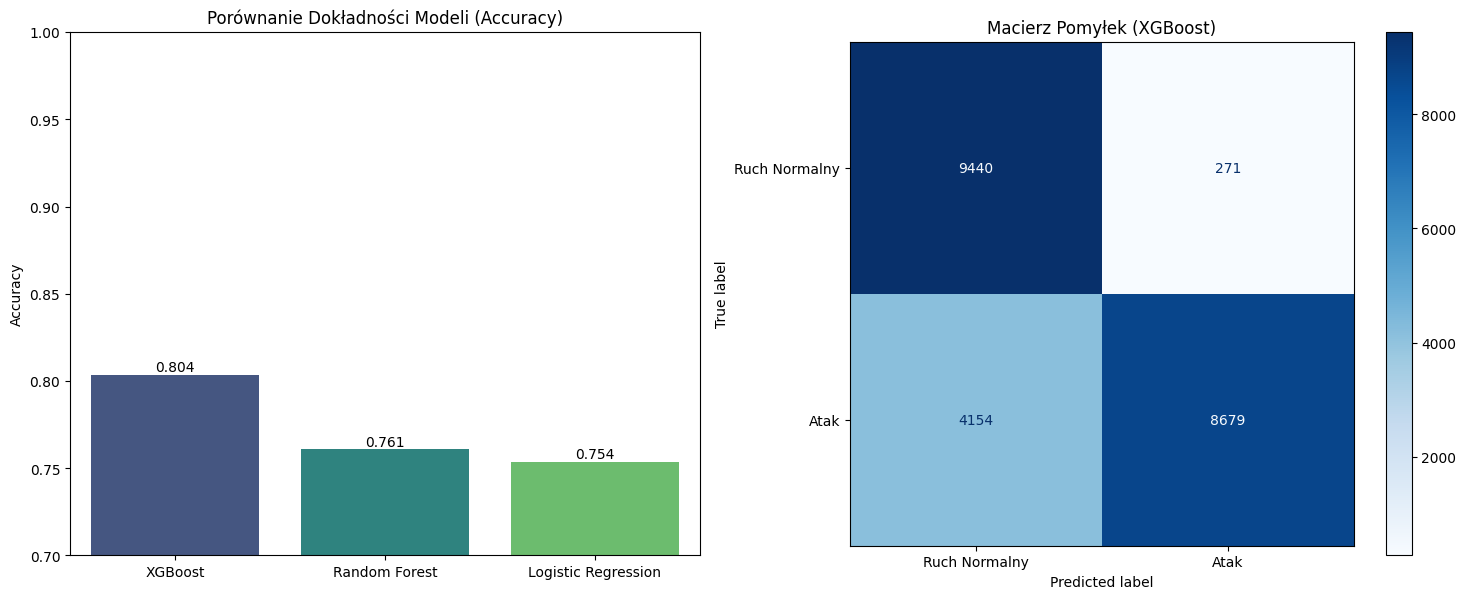

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

results = {}
preds_dict = {}

# Pętla przez każdy model by zebrać predykcje i wynik Accuracy
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    preds_dict[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"[{name}] Dokładność (Accuracy): {round(acc, 4) * 100}%")

print("\n=================== Podsumowanie Modelu - XGBoost ===================")
print(classification_report(y_test, preds_dict["XGBoost"], target_names=["Normalny (0)", "Atak (1)"]))

# Porównanie wyników (Wykres słupkowy)
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Subplot 1: Wykres Accuracy
sns.barplot(x=list(results.keys()), y=list(results.values()), ax=axes[0], palette="viridis")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('Porównanie Dokładności Modeli (Accuracy)')
axes[0].set_ylabel('Accuracy')

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Subplot 2: Macierz pomyłek na bazie najlepszego (zapewne XGBoost lub Random Forest)
najlepszy_model = max(results, key=results.get)
print(f"-> Najlepszy model wykryty heurystycznie to: {najlepszy_model}")
cm_best = confusion_matrix(y_test, preds_dict[najlepszy_model])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Ruch Normalny", "Atak"])
disp.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title(f"Macierz Pomyłek ({najlepszy_model})")

plt.tight_layout()
plt.show()

# 5. Jak modele uczyły się wraz z większą ilością danych
Poniższy wykres pokazuje krzywe uczenia (learning curves):
- linia treningowa: skuteczność modelu na danych treningowych,
- linia walidacyjna: skuteczność na walidacji krzyżowej.

Im mniejsza różnica między krzywymi i im wyższa linia walidacyjna, tym lepsza generalizacja modelu.

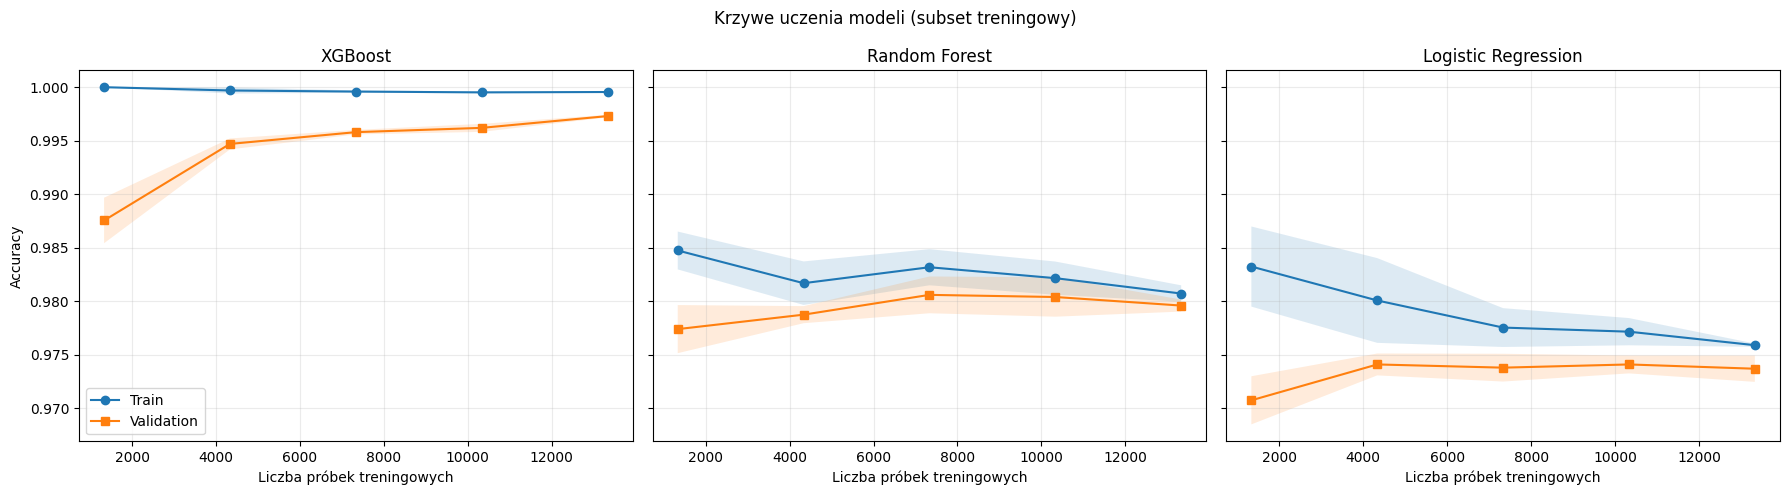

In [13]:
from sklearn.model_selection import learning_curve
import numpy as np

# Użyj mniejszego podzbioru, aby krzywe liczyły się szybciej
subset_size = min(20000, X_train_scaled.shape[0])
X_sub = X_train_scaled[:subset_size]
y_sub = y_train.iloc[:subset_size]

train_sizes = np.linspace(0.1, 1.0, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, model) in zip(axes, trained_models.items()):
    sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_sub,
        y=y_sub,
        train_sizes=train_sizes,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, marker='o', label='Train')
    ax.plot(sizes, val_mean, marker='s', label='Validation')
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel('Liczba próbek treningowych')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('Accuracy')
axes[0].legend()
plt.suptitle('Krzywe uczenia modeli (subset treningowy)')
plt.tight_layout()
plt.show()

# 6. Krótkie Podsumowanie i Wnioski
## Tytuł
Porównanie modeli ML dla detekcji włamań na danych NSL-KDD.

## Ogólne wyniki
- XGBoost: Accuracy = 0.804 (najlepszy wynik).
- Random Forest: Accuracy = 0.761.
- Logistic Regression: Accuracy = 0.754.

## Krótkie wnioski
- Najlepiej poradził sobie XGBoost i to on powinien być modelem bazowym w tym projekcie.
- Random Forest jest dobrym kompromisem między jakością i prostotą.
- Logistic Regression działa jako szybki baseline, ale jest słabsza dla tej złożoności danych.
- Kolejny krok: tuning hiperparametrów (szczególnie XGBoost) pod redukcję false negatives.